# Mediterranean Sea Outflow Water

*Developed starting from activities by Sarah Purkey at Scripps Institution of Oceanography, University of
California San Diego; used in courses such as SIO 210.*

The Mediterranean Sea is an evaporative basin — annually it loses more freshwater to evaporation than it gains from precipitation and river runoff. Yet the Mediterranean maintains a nearly constant salinity. The freshwater deficit is balanced by an exchange of water through the Strait of Gibraltar: relatively fresh Atlantic water flows in, and saltier Mediterranean water flows out. This notebook uses Argo profiles to characterize the interior water masses of the Mediterranean, as well as the inflow and outflow waters at the Strait of Gibraltar; apply Knudsen's relations to estimate exchange transport; and trace Mediterranean Outflow Water (MOW) into the North Atlantic.

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

**How to cite:** If you use this notebook, please cite Sala, J., Giglio, D., Mills, K., & Scanderbeg, M. (2026). *argovis/demo_notebooks* (v0.1.0) [Software]. Zenodo. [https://doi.org/10.5281/zenodo.22032966](https://doi.org/10.5281/zenodo.22032966)

## Notebook structure

- **Part 1** — derive Knudsen's relations from conservation of mass and salt.
- **Part 2** — characterize a "typical" temperature/salinity profile in the Mediterranean interior (Algerian Basin).
- **Part 3** — identify and characterize the inflow and outflow waters at the Strait of Gibraltar.
- **Part 4** — apply Knudsen's relations to estimate the exchange transport.
- **Part 5** — trace Mediterranean Outflow Water (MOW) into the North Atlantic.
- **Student Work** — guided questions throughout each part.

## Learning Goals

By the end of this activity, you will be able to:

1. **Derive Knudsen's relations** from conservation of mass and conservation of salt.
2. **Characterize a "typical" temperature/salinity profile** in the interior of the Mediterranean Sea and identify its major vertical features.
3. **Identify the two water masses** exchanged through the Strait of Gibraltar and determine which is flowing in and which is flowing out.
4. **Apply Knudsen's relations** to estimate the inflow/outflow volume transport through the Strait of Gibraltar from observed salinities and the freshwater imbalance.
5. **Trace Mediterranean Outflow Water (MOW)** into the North Atlantic and describe how its temperature/salinity signature changes with distance from the source.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ──────────────────────────────
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import gsw
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

APIKEY  = 'guest'  # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `traverse_interpolate` — interpolate all queried profiles onto a common pressure grid
- `plot_maps` — scatter profile locations on a map
- `compare_profiles` — plot individual or mean vertical profiles; to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True`
- `average_profiles_dict` — compute level-by-level mean profiles across a list of Profile objects, returned as a single-entry dict ready for `compare_profiles`
- `plot_profiles_TSdiagram` — T/S diagram with optional coloring by a third variable (pressure, distance from the Strait, etc.)
- `compute_derived_properties` — compute SA, CT, potential density, MLD (3 methods), and N² for each profile

In [2]:
# ── Helper functions — run, do not modify ────────────────────────────────────
from notebook_helpers.functions import (
    traverse_query, traverse_interpolate, plot_maps, compare_profiles,
    plot_profiles_TSdiagram, average_profiles_dict,
)
from notebook_helpers.functions_MLD import compute_derived_properties

## Setup: shared configuration

The settings below are used for every region queried in this notebook (the interior Mediterranean, the Strait of Gibraltar, and the Atlantic outflow region). You do not need to edit this cell — only the region- and time-specific settings in each part below.

In [3]:
# ── Fixed settings — shared across all regions in this notebook — do not modify ──
VARIABLES            = ['temperature,1', 'salinity,1']   # ',1' = Argo QC flag 1 (good data only)
TEMP_VAR             = 'temperature'
SALT_VAR             = 'salinity'
argo_collections     = {'argo': ','.join(VARIABLES)}
temperature_key      = {'argo': TEMP_VAR}
salinity_key         = {'argo': SALT_VAR}
INTERPOLATION_LEVELS = list(range(0, 1501, 5))
DATASET_COLORS       = {'argo': 'red'}
MARKER               = ['o']
LINESTYLE            = ['-']

---
## Part 1 — Knudsen's Relations

You can derive Knudsen's relations from conservation of mass and conservation of salt to find that:

$$V_i = \frac{F\,S_o}{S_i - S_o}, \qquad V_o = \frac{F\,S_i}{S_i - S_o}$$

where $V_i$ = volume transport in, $V_o$ = volume transport out, $S_i$ = salinity of the inflowing water, $S_o$ = salinity of the outflowing water, and $F$ = freshwater imbalance ($F$ = river runoff + precipitation − evaporation).

## ✏️ Student Work — Question 1: Derive Knudsen's Relations

Derive Knudsen's relationship from conservation of mass and conservation of salt. Show your work.

*Double-click to edit this cell and write your answer.*

---
## Part 2 — A "Typical" Profile in the Mediterranean Interior

Plot a "typical" salinity and temperature profile in the interior of the Mediterranean Sea.

By default, Step 1 below queries a 3-month window of Argo profiles from a box in the deep Algerian Basin, east of the Strait of Gibraltar (i.e. east of the Alboran Basin) — you do not need to do anything on the Argovis website to get started. If you would like to explore a different region or time window instead, you can change `INTERIOR_BOX` and `INTERIOR_TIME` in the **Step 0 — Configuration** cell below:

- **To choose your own box:** go to [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo), pan/zoom to the region you want, and use the **Shapes** tool to draw a polygon or rectangle. Read off the corner coordinates it reports and use them as `INTERIOR_BOX`, in the form `[[lon_min, lat_min], [lon_max, lat_max]]`.
- **To choose your own dates:** use the date picker on the same page (limited to a 3-month span per query — a longer range returns an error in the web app) and copy the start/end dates into `INTERIOR_TIME`.

In this notebook, the region you select in the web app is approximated by a rectangular **bounding box** (`box`), queried directly through the Argovis API — the same region-selection idea, applied in code.

### Step 0 — Configuration

✏️ **Student Work — Interior Region**

The defaults below already work — run the notebook as-is to query the deep Algerian Basin over a 3-month window. If you would like a different region or time window (see above for how to find one), adjust `INTERIOR_BOX` and `INTERIOR_TIME` — and update `INTERIOR_REGION_NAME` to match, so the plot titles and legend labels below stay correct.

In [4]:
# MODIFY HERE
# ── Shape 1: deep Algerian Basin, interior Mediterranean, east of the Strait ──
INTERIOR_REGION_NAME = 'Algerian Basin'   # ← update this if you choose a different region below
INTERIOR_BOX  = [[1.0, 37.5], [5.0, 39.5]]   # [[lon_min, lat_min], [lon_max, lat_max]]
INTERIOR_TIME = {'startDate': '2022-01-01T00:00:00Z', 'endDate': '2022-04-01T00:00:00Z'}  # ≤ 3 months

# ── built on the fly (do not modify) ──────────────────────────────────────────
interior_region = [{'box': INTERIOR_BOX}]
interior_time   = [INTERIOR_TIME]

### Step 1 — Query and interpolate profiles

In [5]:
# ── Step 1: Query and interpolate — run, do not modify ───────────────────────
interior_results  = traverse_query(interior_region, interior_time, argo_collections,
                                   avh.queryProfile, apikey=APIKEY, apiroot=APIROOT)
interior_profiles = traverse_interpolate(interior_results, INTERPOLATION_LEVELS)

interior_flat = [p for rl in interior_profiles.get('argo', []) for tl in rl for p in tl]
print(f"Loaded {len(interior_flat)} profile(s) in the interior box")

Loaded 84 profile(s) in the interior box


### Step 2 — Compute derived properties

In [6]:
# ── Compute derived properties — run, do not modify ──────────────────────────
for p in interior_flat:
    if p.hasvar(TEMP_VAR) and p.hasvar(SALT_VAR):
        compute_derived_properties(p, temperature_key, salinity_key, 'argo')

print(f"✓ Derived properties computed for {len(interior_flat)} profiles")

✓ Derived properties computed for 84 profiles


### Step 3 — Map of profile locations

Check that the profiles fall within the deep Algerian Basin, east of the Strait of Gibraltar (i.e. east of the Alboran Basin).

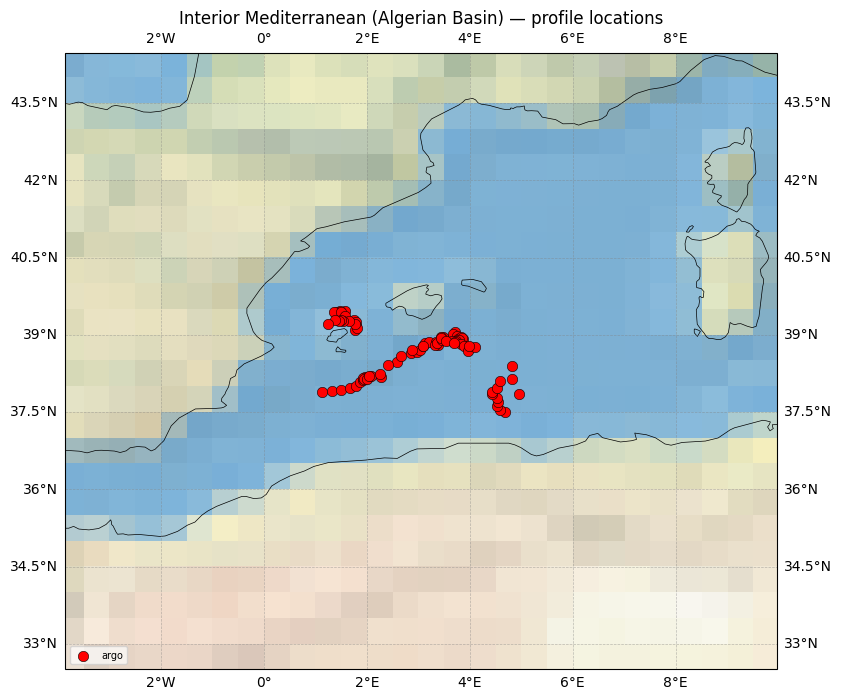

<GeoAxes: title={'center': 'Interior Mediterranean (Algerian Basin) — profile locations'}>

In [7]:
# ── Map — run, do not modify ──────────────────────────────────────────────────
plot_maps(
    [[p.latitude for p in interior_flat]], [[p.longitude for p in interior_flat]],
    title=f'Interior Mediterranean ({INTERIOR_REGION_NAME}) — profile locations',
    labels=['argo'], colors=['red'], markers=MARKER, margin=5,
)

### Step 4 — Full-depth temperature and salinity profiles

The panels below show every profile in the box (thin lines) with the mean "typical" profile overlaid (bold line). The mean profile may look shallower than some of the individual profiles — it is only computed at depths where *every* profile in the box has data, so it stops at the depth of the shallowest profile in your selection, even though other profiles extend deeper.

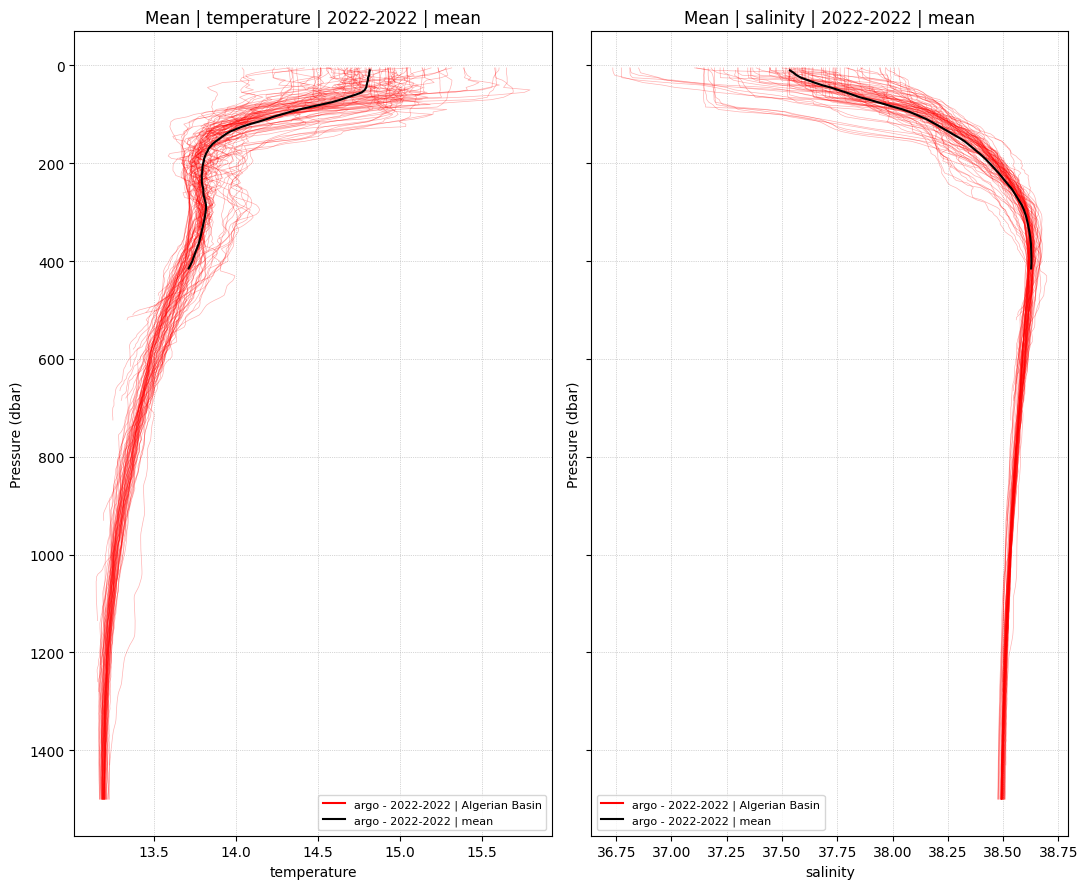

In [8]:
# ── Full-depth T and S profiles, individual + mean — run, do not modify ──────
interior_mean = average_profiles_dict({'argo': interior_flat})

fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(11, 9), sharey=True)

for ax, var in [(ax_t, TEMP_VAR), (ax_s, SALT_VAR)]:
    h1 = compare_profiles({'argo': interior_flat}, varname=var, dataset_colors=DATASET_COLORS,
                          time_linestyles=LINESTYLE, region_label=INTERIOR_REGION_NAME, ax=ax)
    h2 = compare_profiles(interior_mean, varname=var, dataset_colors={'argo': 'black'},
                          time_linestyles=LINESTYLE, mean_style=True, region_label='mean',
                          ax=ax)
    ax.legend(handles=h1 + h2, fontsize=8, loc='best')

plt.tight_layout()
plt.show()

## ✏️ Student Work — Question 2: Full-Depth Profile Features

Export and save the full-depth profile figure above. Discuss what features you see with your group. Where is the water column well-mixed, and where is it stratified?

*Double-click to edit this cell and write your answer.*

### Step 5 — Zoom to the upper 500 m

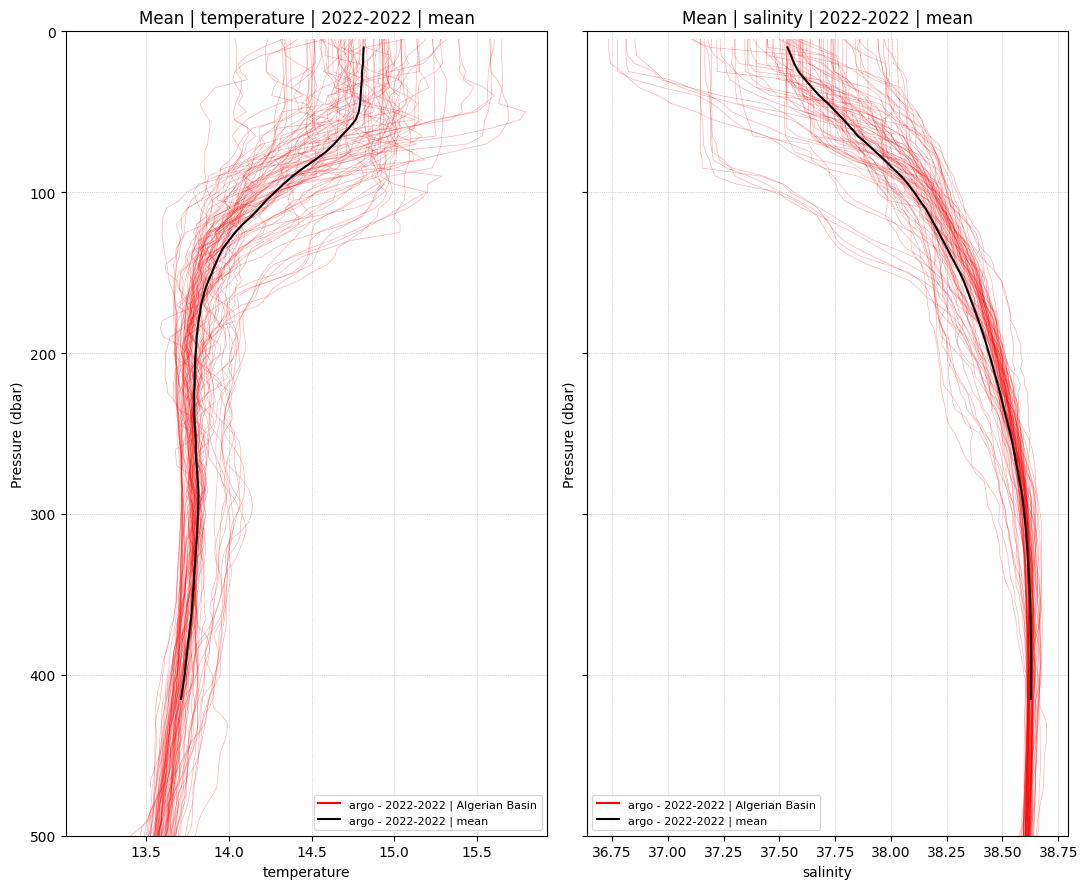

In [9]:
# ── Upper 500 m T and S profiles — run, do not modify ────────────────────────
fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(11, 9), sharey=True)

for ax, var in [(ax_t, TEMP_VAR), (ax_s, SALT_VAR)]:
    h1 = compare_profiles({'argo': interior_flat}, varname=var, dataset_colors=DATASET_COLORS,
                          time_linestyles=LINESTYLE, depth_ylim=500,
                          region_label=INTERIOR_REGION_NAME, ax=ax)
    h2 = compare_profiles(interior_mean, varname=var, dataset_colors={'argo': 'black'},
                          time_linestyles=LINESTYLE, depth_ylim=500, mean_style=True,
                          region_label='mean', ax=ax)
    ax.legend(handles=h1 + h2, fontsize=8, loc='best')

plt.tight_layout()
plt.show()

## ✏️ Student Work — Question 3: Upper 500 m Temperature and Salinity Extrema

Save and discuss the upper-500 m figure. Where are the local temperature and salinity maxima and minima? Hypothesize with your group what drives these features.

*Double-click to edit this cell and write your answer.*

---
## Part 3 — Properties of the Inflow and Outflow Waters

Now define a second shape in the Strait of Gibraltar. You may need to walk through a few 3-month time periods to find a good float — many floats have traveled through the strait, and one of these makes a great option. Note that a float will appear to shoal as it crosses the bathymetry constraining the flow.

If you find a profile in the region, you can also navigate to the platform page, which shows the float's full trajectory, and select the profile you want from there.

### Step 0 — Configuration

✏️ **Student Work — Strait Region**

Adjust `STRAIT_BOX` and `STRAIT_TIME` to match your chosen shape and time window in the Strait of Gibraltar. The Strait is narrow and Argo coverage is sparse, so you may need to try a few different windows before a profile turns up.

In [10]:
# MODIFY HERE
# ── Shape 2: Strait of Gibraltar ──────────────────────────────────────────────
STRAIT_REGION_NAME = 'Strait of Gibraltar'   # ← update this if you choose a different region below
STRAIT_BOX  = [[-5.9, 35.75], [-5.3, 36.05]]  # [[lon_min, lat_min], [lon_max, lat_max]]
STRAIT_TIME = {'startDate': '2020-01-01T00:00:00Z', 'endDate': '2022-04-01T00:00:00Z'}  # ≤ 3 months

# ── built on the fly (do not modify) ──────────────────────────────────────────
strait_region = [{'box': STRAIT_BOX}]
strait_time   = [STRAIT_TIME]

### Step 1 — Query and interpolate profiles

In [11]:
# ── Step 1: Query and interpolate — run, do not modify ───────────────────────
strait_results  = traverse_query(strait_region, strait_time, argo_collections,
                                 avh.queryProfile, apikey=APIKEY, apiroot=APIROOT)
strait_profiles = traverse_interpolate(strait_results, INTERPOLATION_LEVELS)

strait_flat = [p for rl in strait_profiles.get('argo', []) for tl in rl for p in tl]
print(f"Loaded {len(strait_flat)} profile(s) in the Strait of Gibraltar")

Loaded 3 profile(s) in the Strait of Gibraltar


### Step 2 — Compute derived properties

In [12]:
# ── Compute derived properties — run, do not modify ──────────────────────────
for p in strait_flat:
    if p.hasvar(TEMP_VAR) and p.hasvar(SALT_VAR):
        compute_derived_properties(p, temperature_key, salinity_key, 'argo')

print(f"✓ Derived properties computed for {len(strait_flat)} profiles")

✓ Derived properties computed for 3 profiles


### Step 3 — Map of profile locations

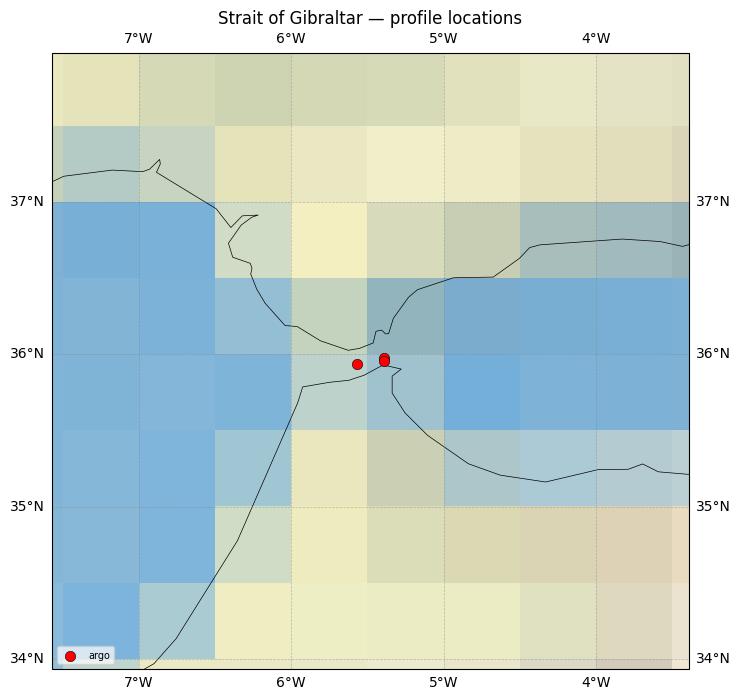

<GeoAxes: title={'center': 'Strait of Gibraltar — profile locations'}>

In [13]:
# ── Map — run, do not modify ──────────────────────────────────────────────────
plot_maps(
    [[p.latitude for p in strait_flat]], [[p.longitude for p in strait_flat]],
    title=f'{STRAIT_REGION_NAME} — profile locations',
    labels=['argo'], colors=['red'], markers=MARKER, margin=2,
)

### Step 4 — Salinity and temperature profile, and T–S diagram

The exchange through the strait is vertically stratified, so you should see two distinct water masses in the profile below — one fresher, one saltier.

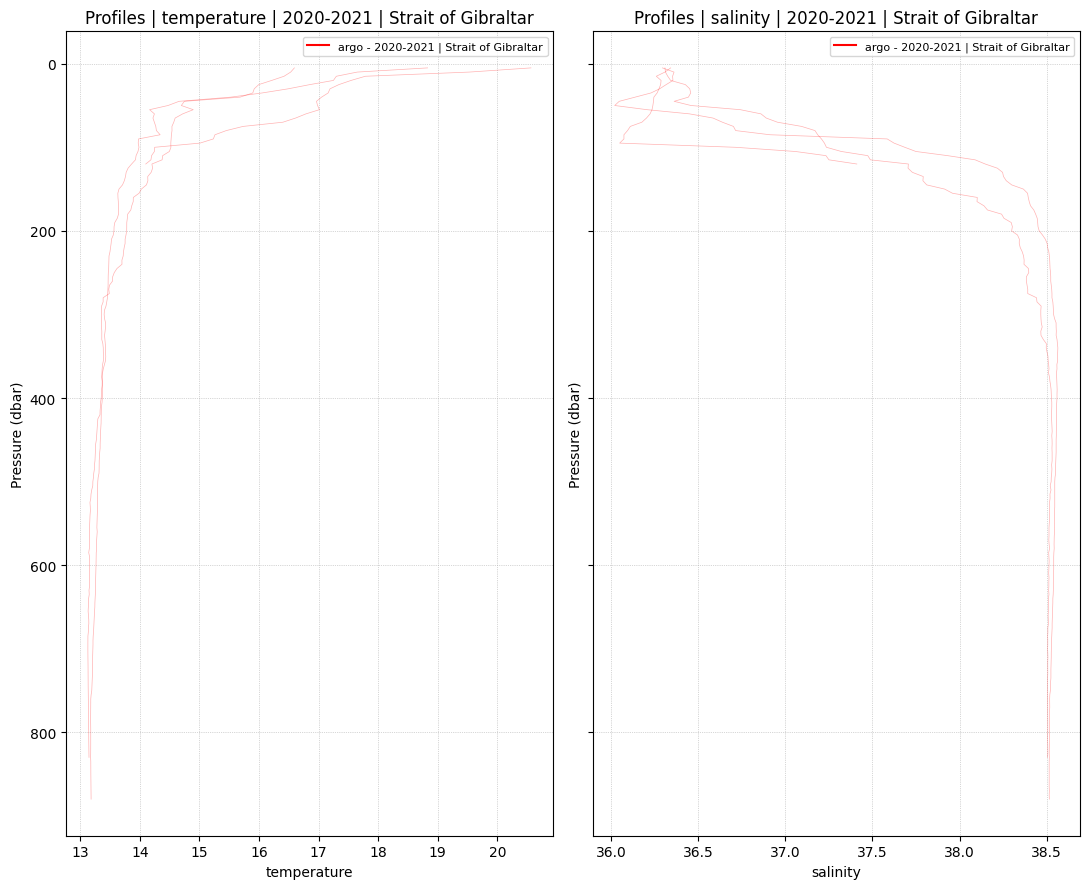

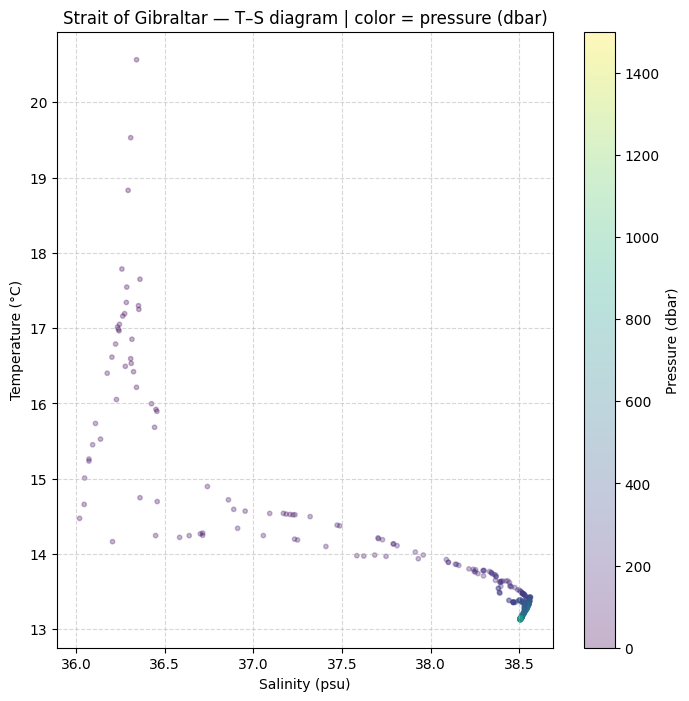

In [14]:
# ── Salinity/temperature profiles + T-S diagram — run, do not modify ─────────
fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(11, 9), sharey=True)

for ax, var in [(ax_t, TEMP_VAR), (ax_s, SALT_VAR)]:
    h = compare_profiles({'argo': strait_flat}, varname=var, dataset_colors=DATASET_COLORS,
                         time_linestyles=LINESTYLE, region_label=STRAIT_REGION_NAME, ax=ax)
    ax.legend(handles=h, fontsize=8, loc='best')

plt.tight_layout()
plt.show()

valuesT    = [p.getvar(TEMP_VAR) for p in strait_flat]
valuesS    = [p.getvar(SALT_VAR) for p in strait_flat]
valuesPres = [p.getvar('pressure') for p in strait_flat]

plot_profiles_TSdiagram(
    valuesT, valuesS, 'Temperature (°C)', 'Salinity (psu)',
    values_to_color=valuesPres,
    title=f'{STRAIT_REGION_NAME} — T–S diagram | color = pressure (dbar)',
    fig_settings={'cbar_label': 'Pressure (dbar)'},
)

### Step 5 — Mean salinity and depth of each water mass

✏️ **Student Work — Layer Ranges**

Using the salinity profile above, read off the approximate depth range of the upper (fresher) layer and the lower (saltier) layer. Write these depths in the cell of code below.

In [15]:
# MODIFY HERE — depth ranges (dbar) bounding each water mass, from the profile above
UPPER_LAYER_RANGE = (0, 100)     # fresher water mass
LOWER_LAYER_RANGE = (150, 300)   # saltier water mass

In [16]:
# ── Mean salinity of each layer — run, do not modify ─────────────────────────
def _layer_mean(profiles, varname, depth_range):
    vals = []
    for p in profiles:
        v = np.asarray(p.getvar(varname), dtype=float)
        z = np.asarray(p.getvar('pressure'), dtype=float)
        mask = (z >= depth_range[0]) & (z <= depth_range[1])
        if mask.any():
            vals.append(np.nanmean(v[mask]))
    return float(np.nanmean(vals)) if vals else np.nan

S_upper = _layer_mean(strait_flat, SALT_VAR, UPPER_LAYER_RANGE)
S_lower = _layer_mean(strait_flat, SALT_VAR, LOWER_LAYER_RANGE)
z_upper = np.mean(UPPER_LAYER_RANGE)
z_lower = np.mean(LOWER_LAYER_RANGE)

print(f"Upper (fresher) layer — depth {UPPER_LAYER_RANGE} dbar, mean salinity = {S_upper:.3f} psu")
print(f"Lower (saltier) layer — depth {LOWER_LAYER_RANGE} dbar, mean salinity = {S_lower:.3f} psu")

Upper (fresher) layer — depth (0, 100) dbar, mean salinity = 36.511 psu
Lower (saltier) layer — depth (150, 300) dbar, mean salinity = 38.397 psu


## ✏️ Student Work — Question 4: Identifying Inflow vs. Outflow Water

Which water mass from Step 4/5 is flowing **in** (into the Mediterranean), and which is flowing **out** (into the Atlantic)? Use the salinity and depth of each layer to justify your answer.

*Double-click to edit this cell and write your answer.*

---
## Part 4 — Applying Knudsen's Relations

From observation, the annual-average freshwater imbalance ($R + P - E$) is $F = -0.04$ Sv. Use the mean salinities of the inflowing and outflowing water masses from Part 3 to calculate the inflow and outflow volume transport.

### Step 1 — Configuration

✏️ **Student Work — Assign inflow/outflow**

Based on your answer to **Question 4** (which water mass is flowing in vs. out, from Part 3), assign `S_i` (salinity of the water flowing **in**) to that layer's mean salinity, and `S_o` (salinity of the water flowing **out**) to the other layer's mean salinity — both computed in Part 3, Step 5.

In [17]:
# MODIFY HERE
F = -0.04  # Sv — annual-average freshwater imbalance (R + P - E)

S_i = S_upper   # salinity of the inflowing water — update if your layers are reversed
S_o = S_lower   # salinity of the outflowing water

In [18]:
# ── Knudsen's relations — run, do not modify ──────────────────────────────────
V_i = F * S_o / (S_i - S_o)
V_o = F * S_i / (S_i - S_o)

print(f"S_i (inflow salinity)    = {S_i:.3f} psu")
print(f"S_o (outflow salinity)   = {S_o:.3f} psu")
print(f"V_i (inflow transport)   = {V_i:.3f} Sv")
print(f"V_o (outflow transport)  = {V_o:.3f} Sv")
print(f"V_o - V_i                = {V_o - V_i:.3f} Sv  (should equal F = {F} Sv)")

S_i (inflow salinity)    = 36.511 psu
S_o (outflow salinity)   = 38.397 psu
V_i (inflow transport)   = 0.814 Sv
V_o (outflow transport)  = 0.774 Sv
V_o - V_i                = -0.040 Sv  (should equal F = -0.04 Sv)


## ✏️ Student Work — Question 5: Salt and Mass Equilibrium

Discuss as a group, in words, what is happening physically and how the salt/mass equilibrium of the Mediterranean is achieved.

*Double-click to edit this cell and write your answer.*

---
## Part 5 — Mediterranean Outflow Water (MOW)

The salty water that flows out through the Strait of Gibraltar mixes with ambient waters in the North Atlantic to form a warm, salty water mass called **Mediterranean Outflow Water (MOW)**.

Define a larger shape that extends from the mouth of the strait out into the Atlantic (e.g. to the mid-Atlantic ridge, and roughly as far north as south). Since this region is larger, you only need ~15–30 days of data — a longer window can be slow to load.

### Step 0 — Configuration

✏️ **Student Work — MOW Region**

The defaults below already work — run the notebook as-is to query a box extending from the Strait mouth into the Atlantic over a 15-day window. If you would like a different region or time window, adjust `MOW_BOX` and `MOW_TIME` — and update `MOW_REGION_NAME` to match, so the plot titles and legend labels below stay correct.

In [19]:
# MODIFY HERE
# ── Shape 3: mouth of the Strait out into the North Atlantic ─────────────────
MOW_REGION_NAME = 'Strait mouth to North Atlantic'   # ← update this if you choose a different region below
MOW_BOX  = [[-15.0, 33.0], [-5.5, 39.0]]   # [[lon_min, lat_min], [lon_max, lat_max]]
MOW_TIME = {'startDate': '2022-01-01T00:00:00Z', 'endDate': '2022-01-21T00:00:00Z'}  # ~15-30 days

# ── built on the fly (do not modify) ──────────────────────────────────────────
mow_region = [{'box': MOW_BOX}]
mow_time   = [MOW_TIME]

# Approximate location of the Strait mouth, used below to measure distance
STRAIT_MOUTH = (-5.6, 35.9)   # (lon, lat)

### Step 1 — Query and interpolate profiles

In [20]:
# ── Step 1: Query and interpolate — run, do not modify ───────────────────────
mow_results  = traverse_query(mow_region, mow_time, argo_collections,
                              avh.queryProfile, apikey=APIKEY, apiroot=APIROOT)
mow_profiles = traverse_interpolate(mow_results, INTERPOLATION_LEVELS)

mow_flat = [p for rl in mow_profiles.get('argo', []) for tl in rl for p in tl]

# Rank profiles by distance from the Strait mouth (nearest first) — used in Step 5-6
for p in mow_flat:
    p.distance_from_strait = float(np.hypot(p.longitude - STRAIT_MOUTH[0],
                                            p.latitude  - STRAIT_MOUTH[1]))
mow_flat.sort(key=lambda p: p.distance_from_strait)

print(f"Loaded {len(mow_flat)} profile(s) in the MOW region")

Loaded 10 profile(s) in the MOW region


### Step 2 — Compute derived properties

In [21]:
# ── Compute derived properties — run, do not modify ──────────────────────────
for p in mow_flat:
    if p.hasvar(TEMP_VAR) and p.hasvar(SALT_VAR):
        compute_derived_properties(p, temperature_key, salinity_key, 'argo')

print(f"✓ Derived properties computed for {len(mow_flat)} profiles")

✓ Derived properties computed for 10 profiles


### Step 3 — Map of profile locations

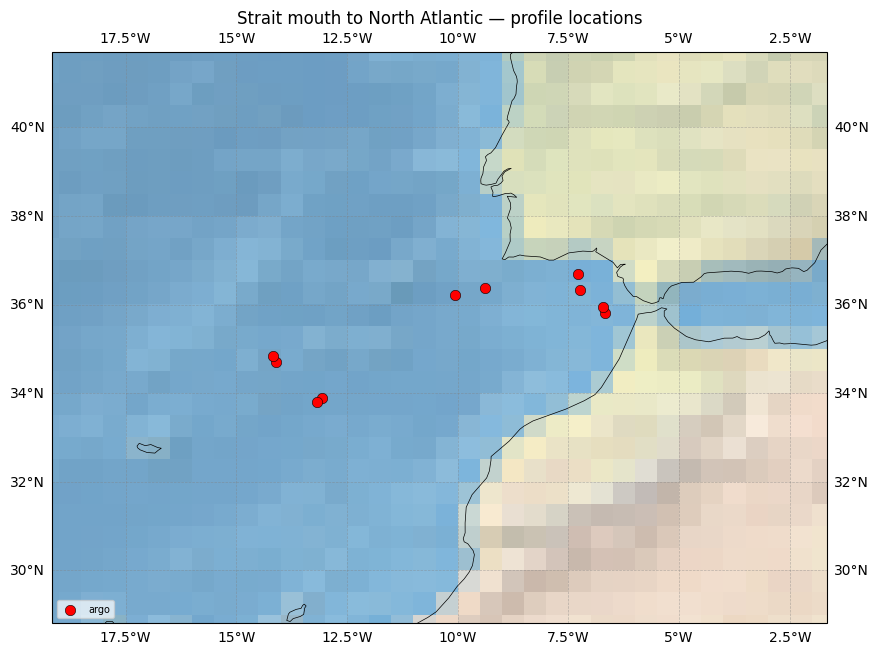

<GeoAxes: title={'center': 'Strait mouth to North Atlantic — profile locations'}>

In [22]:
# ── Map — run, do not modify ──────────────────────────────────────────────────
plot_maps(
    [[p.latitude for p in mow_flat]], [[p.longitude for p in mow_flat]],
    title=f'{MOW_REGION_NAME} — profile locations',
    labels=['argo'], colors=['red'], markers=MARKER, margin=5,
)

### Step 4 — Temperature–pressure, salinity–pressure, and T–S plots over the full region

Look for the MOW signature: a subsurface temperature and salinity maximum at intermediate depths (roughly 700–1200 m), warmer and saltier than the surrounding North Atlantic water.

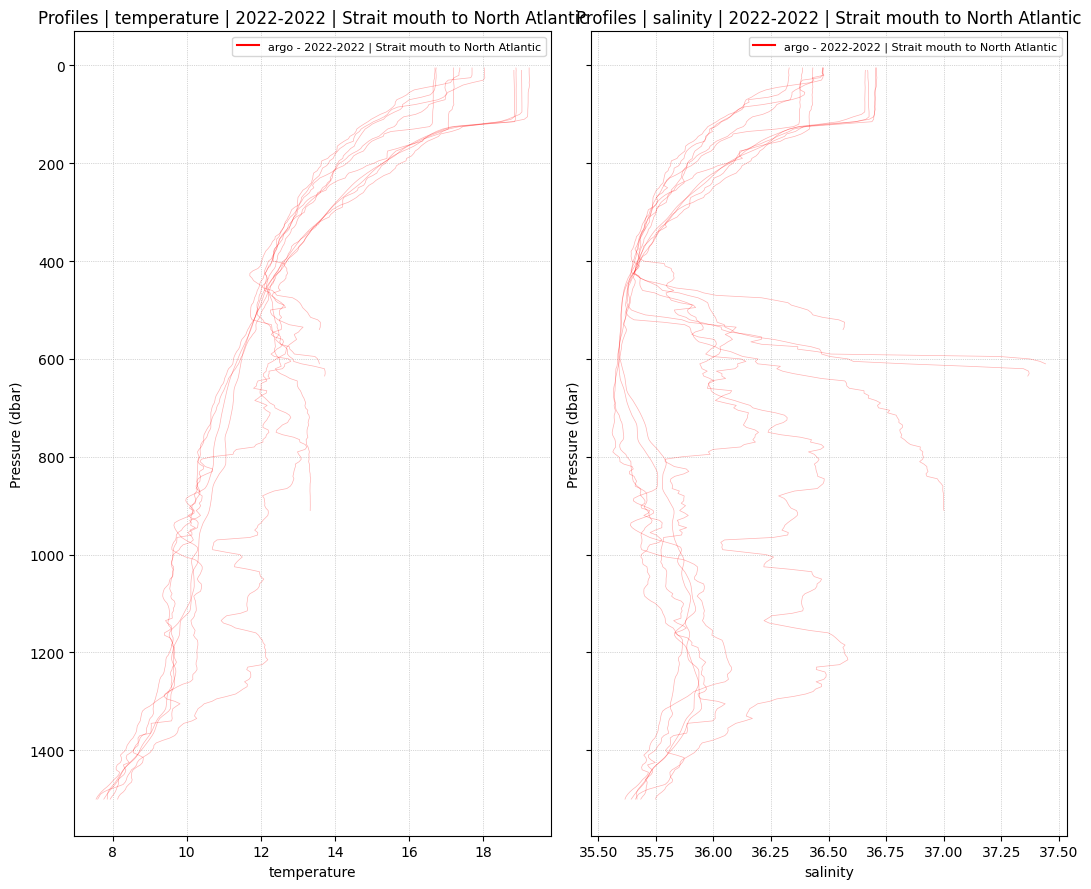

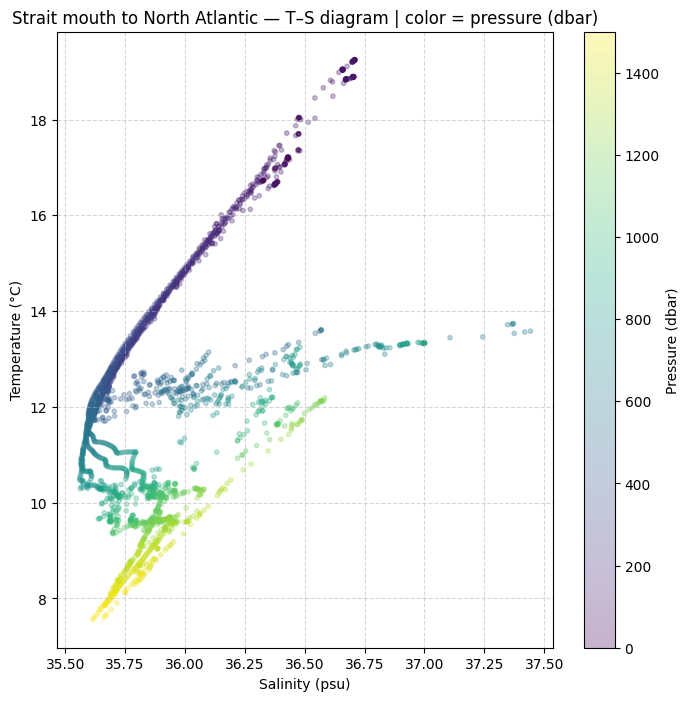

In [23]:
# ── T-P, S-P, and T-S over the full region — run, do not modify ──────────────
fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(11, 9), sharey=True)

for ax, var in [(ax_t, TEMP_VAR), (ax_s, SALT_VAR)]:
    h = compare_profiles({'argo': mow_flat}, varname=var, dataset_colors=DATASET_COLORS,
                         time_linestyles=LINESTYLE, region_label=MOW_REGION_NAME, ax=ax)
    ax.legend(handles=h, fontsize=8, loc='best')

plt.tight_layout()
plt.show()

valuesT    = [p.getvar(TEMP_VAR) for p in mow_flat]
valuesS    = [p.getvar(SALT_VAR) for p in mow_flat]
valuesPres = [p.getvar('pressure') for p in mow_flat]

plot_profiles_TSdiagram(
    valuesT, valuesS, 'Temperature (°C)', 'Salinity (psu)',
    values_to_color=valuesPres,
    title=f'{MOW_REGION_NAME} — T–S diagram | color = pressure (dbar)',
    fig_settings={'cbar_label': 'Pressure (dbar)'},
)

## ✏️ Student Work — Question 6: Identifying MOW in the T–S Diagram

Can you find the MOW signature in the T–S diagram above? What is its approximate salinity and temperature?

*Double-click to edit this cell and write your answer.*

### Step 5 — T–S diagram colored by distance from the Strait

The same points from Step 4, now colored by distance from the Strait mouth, so you can track how the MOW signature changes as it spreads into the Atlantic.

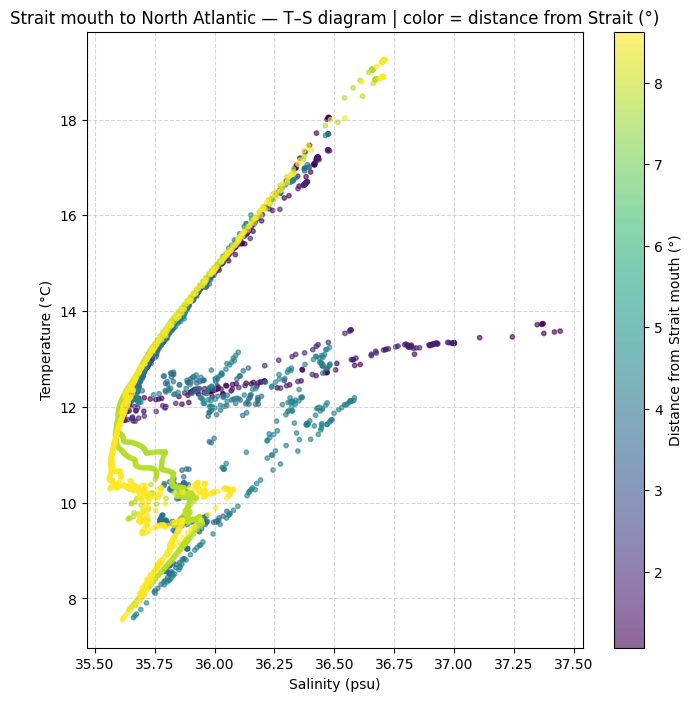

In [24]:
# ── T-S diagram colored by distance from the Strait — run, do not modify ─────
valuesDist = [p.distance_from_strait for p in mow_flat]

plot_profiles_TSdiagram(
    valuesT, valuesS, 'Temperature (°C)', 'Salinity (psu)',
    values_to_color=valuesDist,
    title=f'{MOW_REGION_NAME} — T–S diagram | color = distance from Strait (°)',
    fig_settings={'cbar_label': 'Distance from Strait mouth (°)', 'alpha': 0.6},
)

### Step 6 — Individual profiles at increasing distance

✏️ **Student Work — Select profiles**

Pick a few indices into `mow_flat` (sorted near → far from the Strait) to compare individually. The default spreads them evenly across your sample.

In [25]:
# MODIFY HERE — indices into mow_flat (sorted near -> far from the Strait)
n = len(mow_flat)
SELECTED_IDX = sorted(set([0, n // 3, 2 * n // 3, n - 1])) if n else []

MOW_COLORS = ['#a50026', '#f46d43', '#74add1', '#313695']

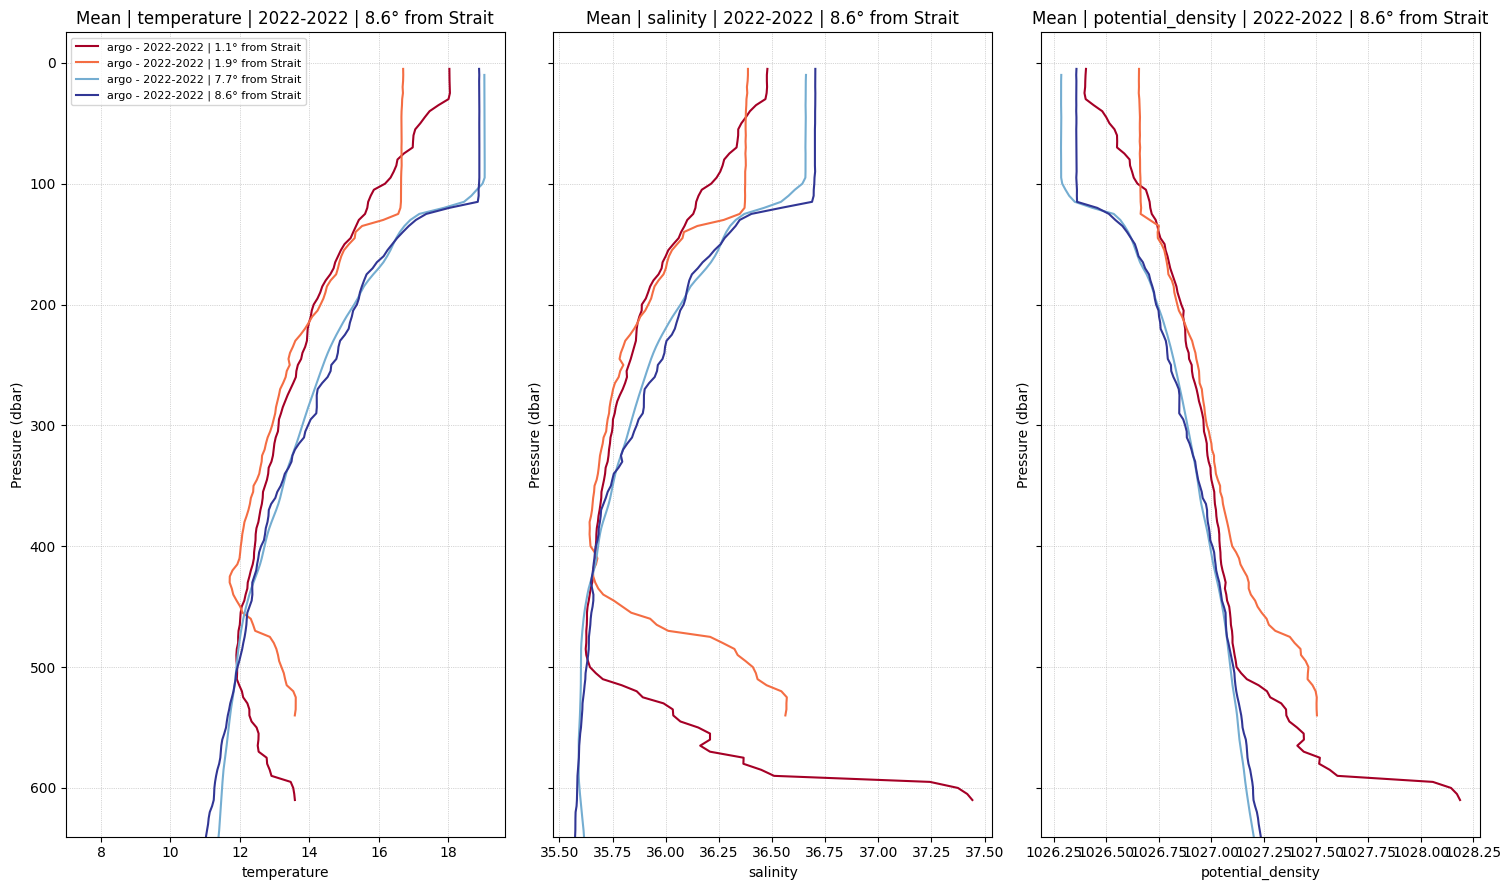

In [26]:
# ── Selected profiles: temperature, salinity, potential density — run, do not modify ──
fig, (ax_t, ax_s, ax_pd) = plt.subplots(1, 3, figsize=(15, 9), sharey=True)

all_handles = []
for col, idx in enumerate(SELECTED_IDX):
    p = mow_flat[idx]
    color = MOW_COLORS[col % len(MOW_COLORS)]
    label = f"{p.distance_from_strait:.1f}° from Strait"
    for ax, var in [(ax_t, TEMP_VAR), (ax_s, SALT_VAR), (ax_pd, 'potential_density')]:
        h = compare_profiles({'argo': [p]}, varname=var, dataset_colors={'argo': color},
                             time_linestyles=LINESTYLE, region_label=label, mean_style=True, ax=ax)
        if ax is ax_t:
            all_handles.extend(h)

ax_t.legend(handles=all_handles, fontsize=8, loc='best')
plt.tight_layout()
plt.show()

## ✏️ Student Work — Question 7: Tracing MOW Away from the Strait

Can you identify the MOW in each profile as you move away from the Strait? What happens to its salinity's and temperature's vertical structure with distance? How far away can you still detect it?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 8: Other Water Masses and MOW Density

What other water masses do you find in the region? Is MOW denser or less dense than the surrounding water? Use the T–S diagram and/or the potential-density panel above to justify your answer.

*Double-click to edit this cell and write your answer.*